In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, multilabel_confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import timm
from transformers import ViTImageProcessor, ViTForImageClassification
import warnings
warnings.filterwarnings('ignore')
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")

# ALL 14 disease labels in the balanced dataset
ALL_DISEASE_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# TARGET classes for multi-label classification (5 classes we actually predict)
TARGET_LABELS = ['Infiltration', 'Consolidation', 'Pneumonia', 'Mass', 'Nodule']

NUM_CLASSES = len(TARGET_LABELS)
print(f"Number of TARGET classes for prediction: {NUM_CLASSES}")
print(f"Target labels: {TARGET_LABELS}")
print(f"Total disease labels in dataset: {len(ALL_DISEASE_LABELS)}")

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
IMAGE_SIZE = 224


Number of TARGET classes for prediction: 5
Target labels: ['Infiltration', 'Consolidation', 'Pneumonia', 'Mass', 'Nodule']
Total disease labels in dataset: 14


In [3]:
# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

# Load dataset
df = pd.read_csv(CSV_PATH)

# Ensure all disease columns exist
required_cols = ['Path'] + ALL_DISEASE_LABELS
if 'No Finding' in df.columns:
    # If No Finding exists, add it but we'll handle it separately
    df_diseases = df[required_cols].copy()
else:
    df_diseases = df[required_cols].copy()

print(f"\nTotal samples in balanced dataset: {len(df_diseases)}")
print(f"Dataset shape: {df_diseases.shape}")

# Check class distribution
print("\nClass distribution in balanced dataset:")
for label in ALL_DISEASE_LABELS:
    count = df_diseases[label].sum()
    percentage = (count / len(df_diseases)) * 100
    print(f"{label:20s}: {count:5d} samples ({percentage:5.2f}%)")

# Prepare multi-label matrix for stratification (all 14 diseases)
X = df_diseases['Path'].values
y_all = df_diseases[ALL_DISEASE_LABELS].values.astype(int)



Total samples in balanced dataset: 51382
Dataset shape: (51382, 15)

Class distribution in balanced dataset:
Atelectasis         :  4788 samples ( 9.32%)
Cardiomegaly        :  4629 samples ( 9.01%)
Consolidation       :  4481 samples ( 8.72%)
Edema               :  4554 samples ( 8.86%)
Effusion            :  5000 samples ( 9.73%)
Emphysema           :  4467 samples ( 8.69%)
Fibrosis            :  5039 samples ( 9.81%)
Hernia              :  5590 samples (10.88%)
Infiltration        :  5740 samples (11.17%)
Mass                :  5564 samples (10.83%)
Nodule              :  5634 samples (10.96%)
Pleural_Thickening  :  4831 samples ( 9.40%)
Pneumonia           :  6105 samples (11.88%)
Pneumothorax        :  4919 samples ( 9.57%)


In [4]:
# ============================================================================
# STRATIFIED MULTI-LABEL SPLIT: Train/Val/Test (60/20/20)
# ============================================================================

print("\n" + "="*70)
print("Creating stratified train/val/test split (60/20/20)...")
print("="*70)

# First split: 60% train, 40% temp (val+test)
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, 
    test_size=0.4, 
    random_state=42
)
train_idx, temp_idx = next(msss.split(X, y_all))

# Second split: Split temp into 50/50 -> 20% val, 20% test of original
msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, 
    test_size=0.5, 
    random_state=42
)
val_idx_temp, test_idx_temp = next(msss2.split(X[temp_idx], y_all[temp_idx]))

# Map back to original indices
val_idx = temp_idx[val_idx_temp]
test_idx = temp_idx[test_idx_temp]

# Create split dataframes
train_df = df_diseases.iloc[train_idx].reset_index(drop=True)
val_df = df_diseases.iloc[val_idx].reset_index(drop=True)
test_df = df_diseases.iloc[test_idx].reset_index(drop=True)

print(f"\nTraining samples:   {len(train_df):5d} ({len(train_df)/len(df_diseases)*100:.1f}%)")
print(f"Validation samples: {len(val_df):5d} ({len(val_df)/len(df_diseases)*100:.1f}%)")
print(f"Test samples:       {len(test_df):5d} ({len(test_df)/len(df_diseases)*100:.1f}%)")

# Verify stratification for TARGET classes
print("\n" + "="*70)
print("Verifying stratification for TARGET classes:")
print("="*70)
for label in TARGET_LABELS:
    train_rate = train_df[label].mean()
    val_rate = val_df[label].mean()
    test_rate = test_df[label].mean()
    print(f"{label:20s}: Train={train_rate:.3f}, Val={val_rate:.3f}, Test={test_rate:.3f}")

# Check that every TARGET class appears in each split
print("\n" + "="*70)
print("Confirming every TARGET class appears in each split:")
print("="*70)
for label in TARGET_LABELS:
    train_count = train_df[label].sum()
    val_count = val_df[label].sum()
    test_count = test_df[label].sum()
    print(f"{label:20s}: Train={train_count:4d}, Val={val_count:4d}, Test={test_count:4d}")
    
    if train_count == 0 or val_count == 0 or test_count == 0:
        print(f"  ⚠️  WARNING: {label} missing in at least one split!")


Creating stratified train/val/test split (60/20/20)...

Training samples:   30829 (60.0%)
Validation samples: 10276 (20.0%)
Test samples:       10277 (20.0%)

Verifying stratification for TARGET classes:
Infiltration        : Train=0.112, Val=0.112, Test=0.112
Consolidation       : Train=0.087, Val=0.087, Test=0.087
Pneumonia           : Train=0.119, Val=0.119, Test=0.119
Mass                : Train=0.108, Val=0.108, Test=0.108
Nodule              : Train=0.110, Val=0.110, Test=0.110

Confirming every TARGET class appears in each split:
Infiltration        : Train=3444, Val=1148, Test=1148
Consolidation       : Train=2689, Val= 896, Test= 896
Pneumonia           : Train=3663, Val=1221, Test=1221
Mass                : Train=3338, Val=1113, Test=1113
Nodule              : Train=3380, Val=1127, Test=1127


In [5]:
# ============================================================================
# IMPORT CUSTOM DATASET CLASS
# ============================================================================
from dataset_handler import NIHChestXrayDataset

print("NIHChestXrayDataset class imported successfully.")

NIHChestXrayDataset class imported successfully.


In [6]:
# ============================================================================
# DATA AUGMENTATION AND TRANSFORMS (Conservative for CXR)
# ============================================================================

# Training transforms with MINIMAL augmentation (CXR-sensitive)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Safe for CXR
    transforms.RandomRotation(degrees=5),    # Reduced to ±5° (was 10°)
    # Removed ColorJitter - CXR intensity values are diagnostically important
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Test transforms (identical to validation)
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

In [7]:
# ============================================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================================

# Create datasets - pass TARGET_LABELS (only 5 classes)
train_dataset = NIHChestXrayDataset(
    train_df, IMAGE_DIR, TARGET_LABELS, transform=train_transforms
)
val_dataset = NIHChestXrayDataset(
    val_df, IMAGE_DIR, TARGET_LABELS, transform=val_transforms
)
test_dataset = NIHChestXrayDataset(
    test_df, IMAGE_DIR, TARGET_LABELS, transform=test_transforms
)

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,  
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print("\n" + "="*70)
print("DataLoaders created successfully!")
print("="*70)
print(f"Number of training batches:   {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches:       {len(test_loader)}")

# Verify output shape
sample_images, sample_labels = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Images: {sample_images.shape}")
print(f"  Labels: {sample_labels.shape} (should be [batch_size, {NUM_CLASSES}])")


DataLoaders created successfully!
Number of training batches:   964
Number of validation batches: 322
Number of test batches:       322

Sample batch shapes:
  Images: torch.Size([32, 3, 224, 224])
  Labels: torch.Size([32, 5]) (should be [batch_size, 5])


In [8]:
# ============================================================================
# MODEL DEFINITION
# ============================================================================

class ViTForMultiLabelClassification(nn.Module):
    """Vision Transformer for multi-label classification"""
    
    def __init__(self, num_classes, pretrained=True):
        super(ViTForMultiLabelClassification, self).__init__()
        
        # Load pretrained ViT model using timm
        self.vit = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )
        
        # Get the feature dimension
        self.feature_dim = self.vit.num_features
        
        # Custom classification head for multi-label
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Extract features
        features = self.vit(x)
        
        # Classification
        logits = self.classifier(features)
        
        return logits

# Initialize model
model = ViTForMultiLabelClassification(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"\nModel architecture:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model architecture:
Total parameters: 21,865,349
Trainable parameters: 21,865,349


In [9]:
# ============================================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================================

# Get the count of positive samples for each class
pos_counts = train_df[TARGET_LABELS].sum()

# Get the count of negative samples for each class
neg_counts = len(train_df) - pos_counts

# Calculate the weight for each class
# weight = negative_samples / positive_samples
pos_weight = neg_counts / pos_counts

# Convert weights to a tensor and send to the GPU
# (Make sure 'device' is defined, e.g., device = 'cuda' if torch.cuda.is_available() else 'cpu')
weights_tensor = torch.tensor(pos_weight.values, dtype=torch.float32).to(device)

print(f"Target Labels: {TARGET_LABELS}")
print(f"Positive Counts: {pos_counts.values}")
print(f"Negative Counts: {neg_counts.values}")
print(f"Calculated Weights: {weights_tensor.cpu().numpy()}")

# --- 2. Create the Weighted Loss Function ---
criterion = nn.BCEWithLogitsLoss(pos_weight=weights_tensor)

# --- 3. The rest of your code is perfect ---
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS
)

Target Labels: ['Infiltration', 'Consolidation', 'Pneumonia', 'Mass', 'Nodule']
Positive Counts: [3444 2689 3663 3338 3380]
Negative Counts: [27385 28140 27166 27491 27449]
Calculated Weights: [ 7.95151   10.464857   7.4163256  8.23577    8.121006 ]


In [10]:
# ============================================================================
# TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        
        # Store predictions and labels
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            
            # Store predictions and labels
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def compute_metrics(labels, predictions, threshold=0.5):
    """Compute evaluation metrics"""
    metrics = {}
    
    # ROC AUC (per class and mean)
    try:
        auc_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:  # Check if both classes present
                auc = roc_auc_score(labels[:, i], predictions[:, i])
                auc_scores.append(auc)
        metrics['auc_mean'] = np.mean(auc_scores) if auc_scores else 0.0
    except:
        metrics['auc_mean'] = 0.0
    
    # Average Precision (per class and mean)
    try:
        ap_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:
                ap = average_precision_score(labels[:, i], predictions[:, i])
                ap_scores.append(ap)
        metrics['ap_mean'] = np.mean(ap_scores) if ap_scores else 0.0
    except:
        metrics['ap_mean'] = 0.0
    
    # Binary predictions for accuracy
    binary_preds = (predictions >= threshold).astype(int)
    
    # Accuracy
    metrics['accuracy'] = np.mean(binary_preds == labels)
    
    return metrics

In [11]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_auc': [],
    'val_auc': [],
    'train_ap': [],
    'val_ap': [],
    'train_acc': [],
    'val_acc': []
}

best_val_auc = 0.0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Train
    train_loss, train_preds, train_labels = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_metrics = compute_metrics(train_labels, train_preds)
    
    # Validate
    val_loss, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    val_metrics = compute_metrics(val_labels, val_preds)
    
    # Update learning rate
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_metrics['auc_mean'])
    history['val_auc'].append(val_metrics['auc_mean'])
    history['train_ap'].append(train_metrics['ap_mean'])
    history['val_ap'].append(val_metrics['ap_mean'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    
    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train AUC: {train_metrics['auc_mean']:.4f} | Val AUC: {val_metrics['auc_mean']:.4f}")
    print(f"Train AP: {train_metrics['ap_mean']:.4f} | Val AP: {val_metrics['ap_mean']:.4f}")
    print(f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    
    # Save best model
    if val_metrics['auc_mean'] > best_val_auc:
        best_val_auc = val_metrics['auc_mean']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': best_val_auc,
        }, 'best_vit_model.pth')
        print(f"✓ Saved best model (Val AUC: {best_val_auc:.4f})")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETED")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}")
print(f"{'='*70}")


STARTING TRAINING

Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [02:02<00:00,  2.64it/s, loss=1.64] 



Train Loss: 1.1361 | Val Loss: 1.0537
Train AUC: 0.6765 | Val AUC: 0.7471
Train AP: 0.2208 | Val AP: 0.3029
Train Acc: 0.6290 | Val Acc: 0.6807
✓ Saved best model (Val AUC: 0.7471)

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [01:53<00:00,  2.85it/s, loss=1.9]  



Train Loss: 1.0422 | Val Loss: 1.0075
Train AUC: 0.7486 | Val AUC: 0.7736
Train AP: 0.3018 | Val AP: 0.3402
Train Acc: 0.6872 | Val Acc: 0.7413
✓ Saved best model (Val AUC: 0.7736)

Epoch 3/10
----------------------------------------------------------------------


...


Train Loss: 0.6928 | Val Loss: 0.9397
Train AUC: 0.8968 | Val AUC: 0.8254
Train AP: 0.5746 | Val AP: 0.4629
Train Acc: 0.8058 | Val Acc: 0.7893
✓ Saved best model (Val AUC: 0.8254)

Epoch 9/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [01:59<00:00,  2.70it/s, loss=2.13]  



Train Loss: 0.6614 | Val Loss: 0.9373
Train AUC: 0.9060 | Val AUC: 0.8256
Train AP: 0.5966 | Val AP: 0.4679
Train Acc: 0.8162 | Val Acc: 0.7893
✓ Saved best model (Val AUC: 0.8256)

Epoch 10/10
----------------------------------------------------------------------


Validation: 100%|██████████| 322/322 [01:58<00:00,  2.71it/s, loss=2.15]  



Train Loss: 0.6452 | Val Loss: 0.9372
Train AUC: 0.9103 | Val AUC: 0.8256
Train AP: 0.6105 | Val AP: 0.4675
Train Acc: 0.8197 | Val Acc: 0.7915
✓ Saved best model (Val AUC: 0.8256)

TRAINING COMPLETED
Best Val AUC: 0.8256 at epoch 10


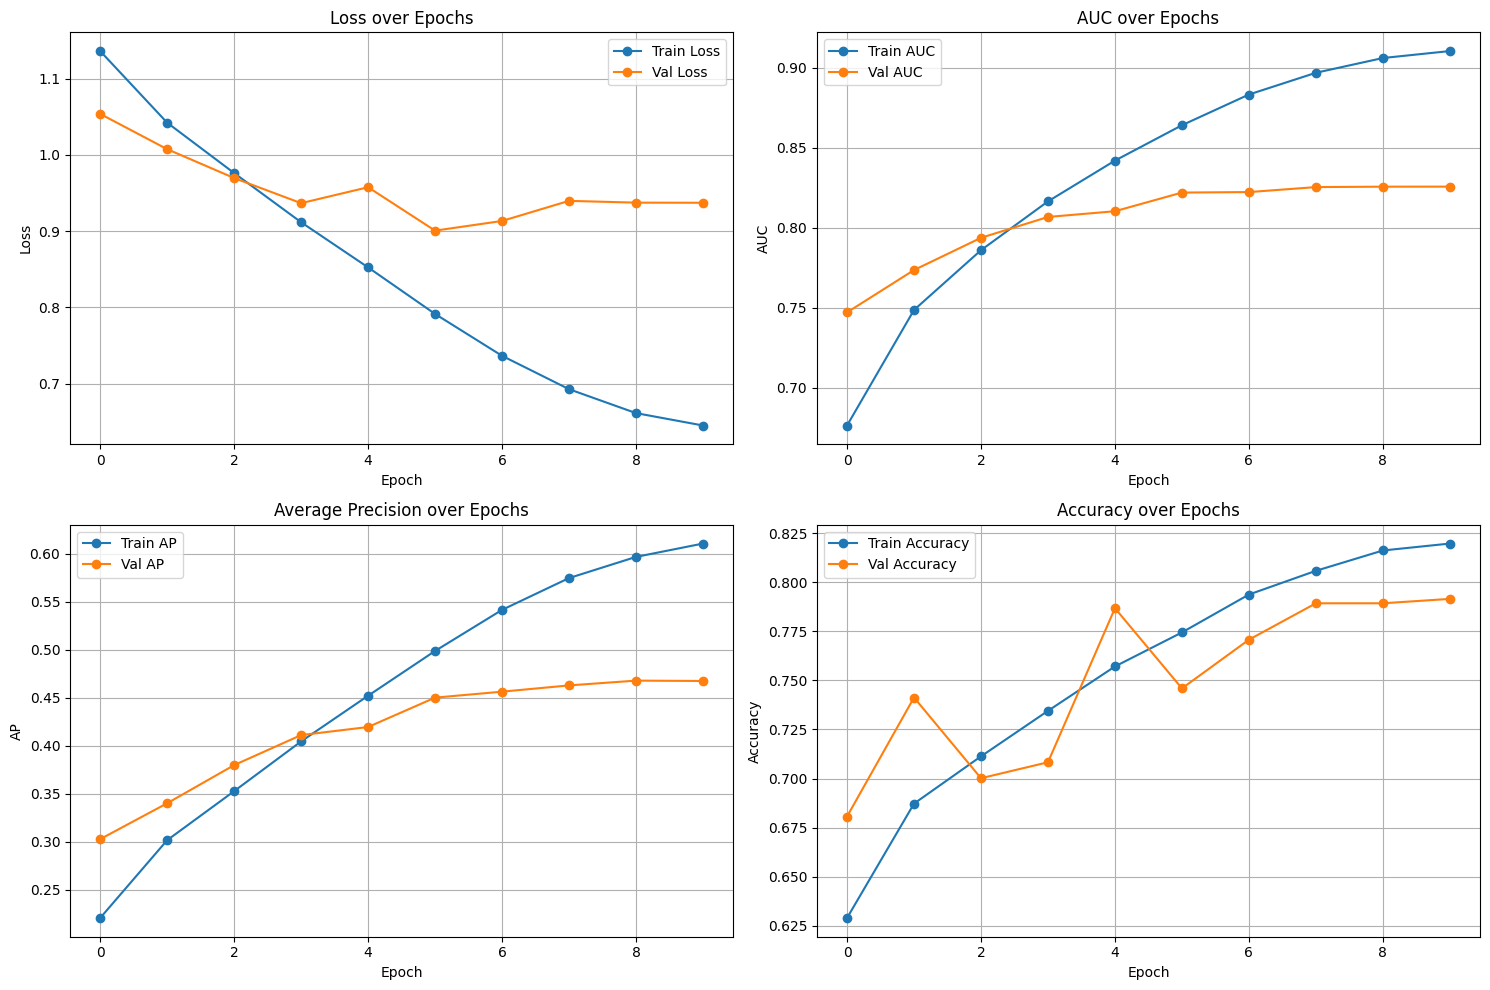


✓ Training history plot saved as 'training_history.png'


In [12]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history['train_auc'], label='Train AUC', marker='o')
axes[0, 1].plot(history['val_auc'], label='Val AUC', marker='o')
axes[0, 1].set_title('AUC over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Average Precision
axes[1, 0].plot(history['train_ap'], label='Train AP', marker='o')
axes[1, 0].plot(history['val_ap'], label='Val AP', marker='o')
axes[1, 0].set_title('Average Precision over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AP')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1, 1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1, 1].set_title('Accuracy over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved as 'training_history.png'")

In [13]:
# ============================================================================
# EVALUATE ON VALIDATION SET WITH BEST MODEL
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON BEST MODEL")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)
val_metrics = compute_metrics(val_labels, val_preds)

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation AUC: {val_metrics['auc_mean']:.4f}")
print(f"Validation AP: {val_metrics['ap_mean']:.4f}")
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")

# Per-class metrics
print(f"\nPer-class AUC scores:")
for i, label in enumerate(DISEASE_LABELS):
    if len(np.unique(val_labels[:, i])) > 1:
        auc = roc_auc_score(val_labels[:, i], val_preds[:, i])
        print(f"  {label:25s}: {auc:.4f}")

print("\n" + "="*70)
print("✓ Training and evaluation complete!")
print("="*70)


FINAL EVALUATION ON BEST MODEL


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([scalar])` or the `torch.serialization.safe_globals([scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weig